In [1]:
from google.colab import files

upload = files.upload()

Saving 85334965-5736-457a-b8d4-a077e6872f84.csv to 85334965-5736-457a-b8d4-a077e6872f84.csv


**PROJECT TITLE**

SIMPLE LINEAR REGRESSION - MARKETING ROI ANALYSIS.

**PROJECT OVERVIEW**
This project analyzes the relationship between marketing expenditure and Sales using Simple Linear Regression. The objective is to identify the marketing channel that has the strongest impact on sales, build an OLS regression model using Statsmodels, validate the model assumptions, and provide business recommendations based on the findings.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [2]:
import pandas as pd

df = pd.read_csv("85334965-5736-457a-b8d4-a077e6872f84.csv")
df.head()

,TV,Radio,Social_Media,Sales
0,16.0,6.566231,2.907983,54.732757
1,13.0,9.237765,2.409567,46.677897
2,41.0,15.886446,2.913410,150.177829
3,83.0,30.020028,6.922304,298.246340
4,15.0,8.437408,1.405998,56.594181


**DATA EXPLORATION & CLEANING**

In this section, the dataset is explored to understand its structure, check for missing values, and prepare it for analysis.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4546 entries, 0 to 4571
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4546 non-null   float64
 1   Radio         4546 non-null   float64
 2   Social_Media  4546 non-null   float64
 3   Sales         4546 non-null   float64
dtypes: float64(4)
memory usage: 177.6 KB


In [9]:
df.describe()

,TV,Radio,Social_Media,Sales
count,4546.000000,4546.000000,4546.000000,4546.000000
mean,54.062912,18.157533,3.323473,192.413332
std,26.104942,9.663260,2.211254,93.019873
min,10.000000,0.000684,0.000031,31.199409
25%,32.000000,10.555355,1.530822,112.434612
50%,53.000000,17.859513,3.055565,188.963678
75%,77.000000,25.640603,4.804919,272.324236
max,100.000000,48.871161,13.981662,364.079751


In [10]:
df.isnull().sum()

,0
TV,0
Radio,0
Social_Media,0
Sales,0


In [6]:
df = df.dropna()

In [11]:
df.corr(numeric_only=True)

,TV,Radio,Social_Media,Sales
TV,1.000000,0.869158,0.527687,0.999497
Radio,0.869158,1.000000,0.606338,0.868638
Social_Media,0.527687,0.606338,1.000000,0.527446
Sales,0.999497,0.868638,0.527446,1.000000


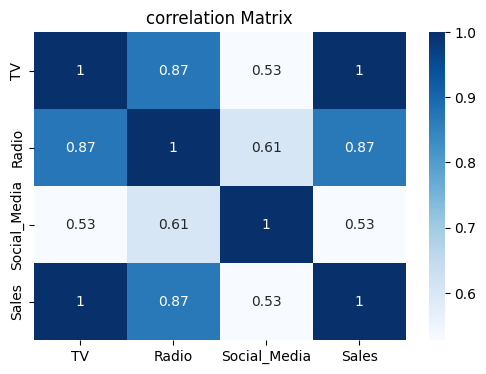

In [12]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="Blues")
plt.title("correlation Matrix")
plt.show()

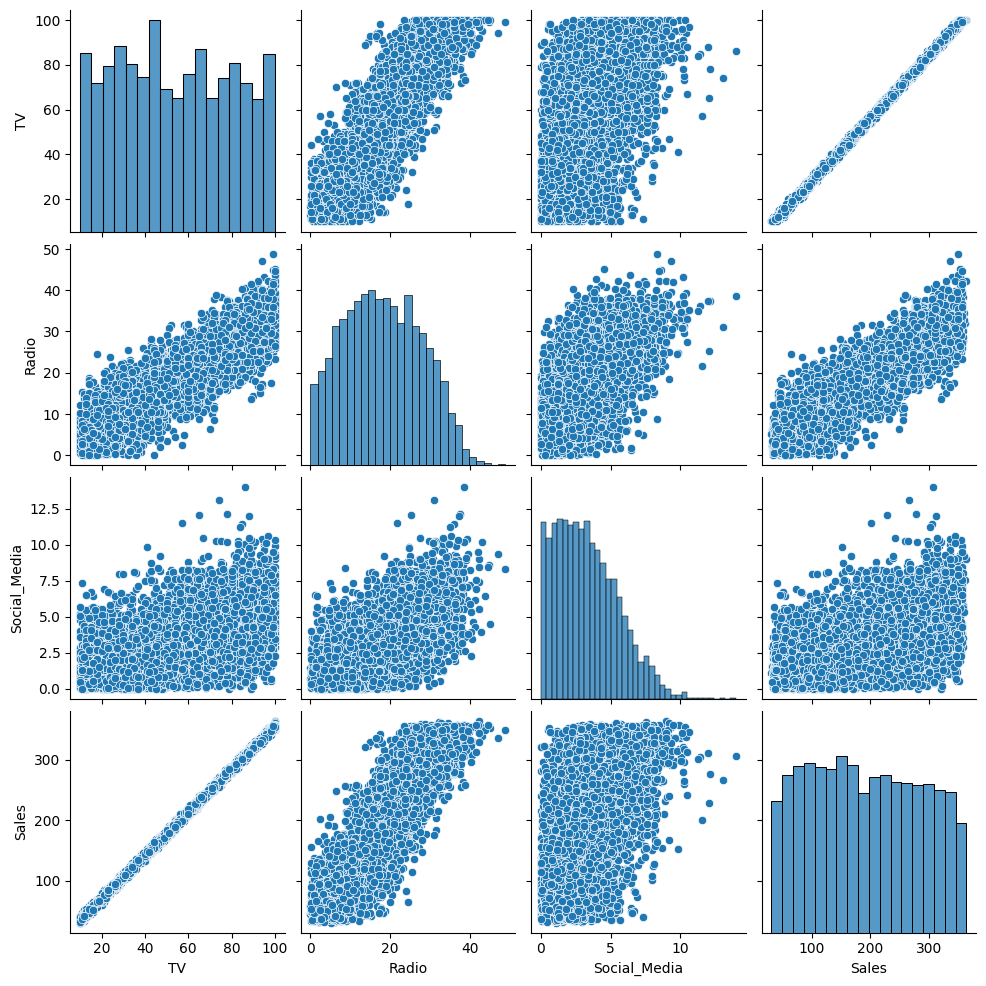

In [13]:
sns.pairplot(df)
plt.show()

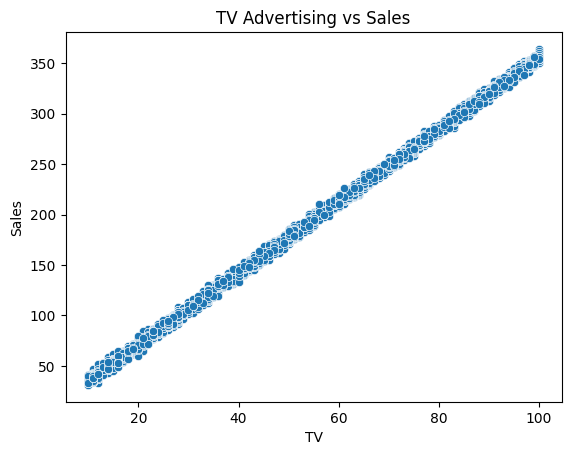

In [14]:
sns.scatterplot(x="TV", y="Sales", data=df)
plt.title("TV Advertising vs Sales")
plt.show()

**VARIABLE SELECTION**

The correlation analysis shows that TV advertising has the strongest relationship with Sales.

Correlation values:

*   TV = 0.9995
*   Radio = 0.8691
*   Social_Media = 0.5289

Therefore, TV is selected as the independent variable for the Simple Linear Regression model.






In [19]:
Y = df['Sales']

x = sm.add_constant(x)

model = sm.OLS(Y, x).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.517e+06
Date:                Fri, 26 Jun 2026   Prob (F-statistic):               0.00
Time:                        11:32:56   Log-Likelihood:                -11366.
No. Observations:                4546   AIC:                         2.274e+04
Df Residuals:                    4544   BIC:                         2.275e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1325      0.101     -1.317      0.1

In [20]:
residuals = model.resid
fitted = model.fittedvalues

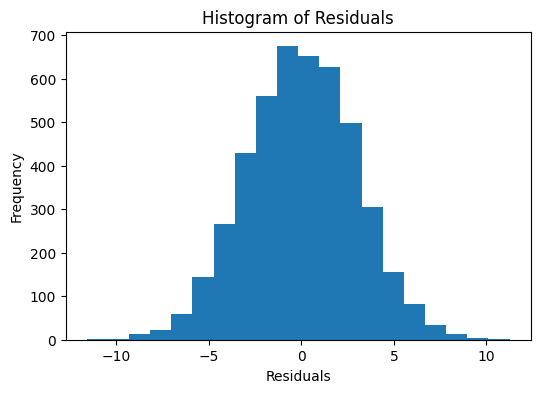

In [21]:
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=20)
plt.title("Histogram of Residuals")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

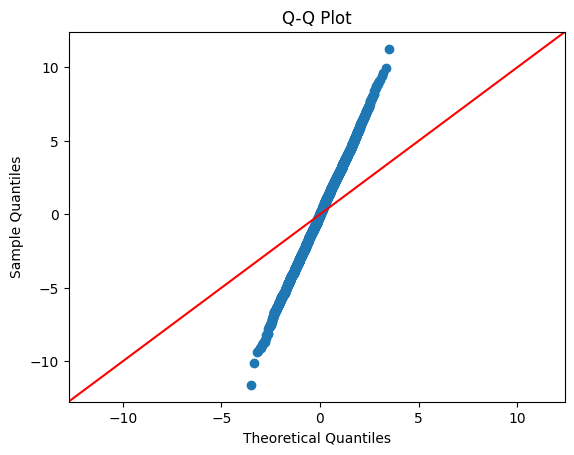

In [22]:
sm.qqplot(residuals, line='45')
plt.title("Q-Q Plot")
plt.show()

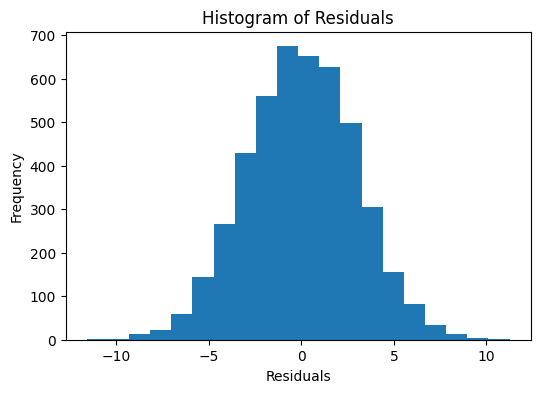

In [23]:
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=20)
plt.title("Histogram of Residuals")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()


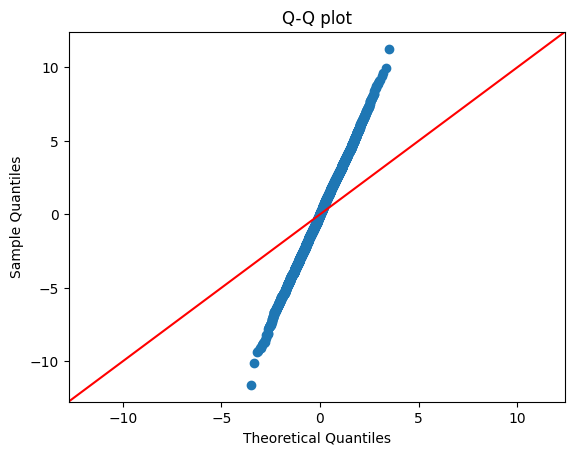

In [24]:
sm.qqplot(residuals, line='45')
plt.title("Q-Q plot")
plt.show()

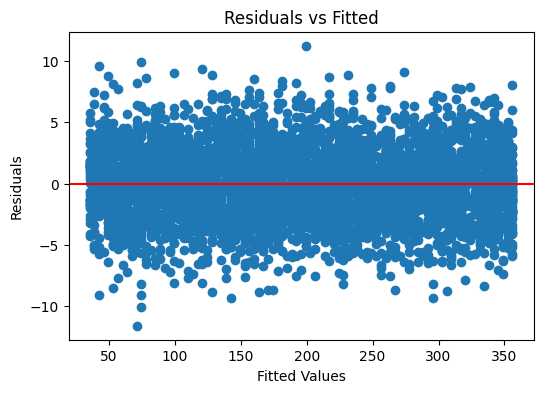

In [25]:
plt.figure(figsize=(6,4))
plt.scatter(fitted, residuals)
plt.axhline(y=0, color='red')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()


INTERPRETATION & EVALUATION

R-squared
The model achieved an R-squared value of 0.999.
This means that approximately 99.9% of the variation in Sales is explained by TV advertising expenditure, indicating an extremely strong relationship between the variables.

COEFFICIENT INTERPRETATION
The coefficient for TV advertising is 3.5615.
This means that for every one - unit increase in TV advertising expenditure, Sales are expected to increase by approximately 3.56 units, holding all other factors constant.

P - VALUE INTERPRETATION.
The p-value for TV is 0.000, which is less than the significance level of 0.05.
This indicates that the relationship between TV advertising and Sales is statistically significant and unlikely to have occurred by chance.

INTERCEPT INTERPRETATION.
The intercept is -0.1325.
This represents the predicted Sales value when TV advertising expenditure is zero.

MODEL EVALUATION.
The high R-squared value and statistically significant p-value suggest that TV advertising is a strong predictor of Sales and that the regression model provides an excellent fit to the data.

CONCLUSION & BUSINESS INSIGHTS

FINAL REGRESSION EQUATION
Sales = (3.5615xTV)-0.1325.

BUSINESS INSIGHTS.
The analysis reveals a strong positive relationship between TV advertising expenditure and Sales.

The regression coefficient indicates that increasing TV advertising expenditure leads to a substantial increase in Sales.

Because the p-value is below 0.05 and the R-squared value is very high (0.999), TV dvertising appears to be highly effective in driving sales performsnce.

RECOMMENDATION
Organizations should consider allocating a larger portion of their marketing budgets to TV advertising, as the model suggests that increased investment in this channel is associated with higher sales and potentially return on investment (ROI)